In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\abhir\\OneDrive\\Desktop\\Anaconda Practice\\csv files\\Walmart_sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
X = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']]
y = df['Weekly_Sales']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [7]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [8]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [9]:
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 475432.53295882524
R2: 0.01738312550370069

Decision Tree:
MAE: 428449.38251618756
R2: -0.24989497234084435

Random Forest:
MAE: 385984.4242717711
R2: 0.09973009581786363


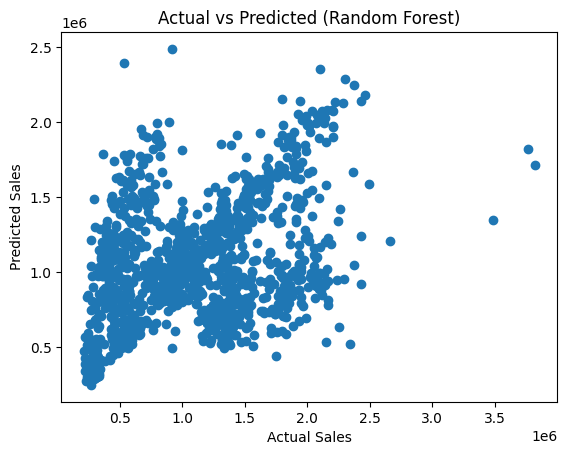

In [10]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 385984.4242717711
R2 Score: 0.09973009581786363


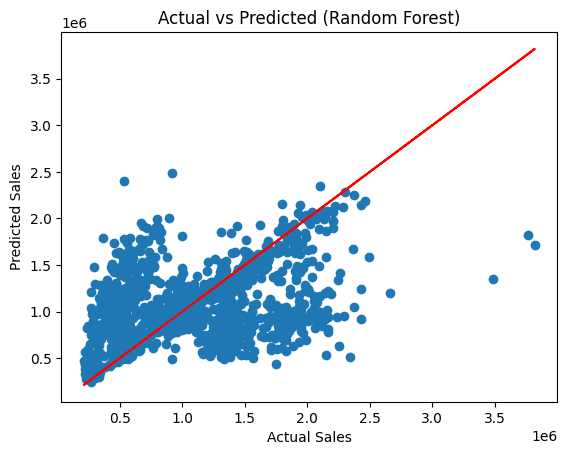

In [13]:
plt.scatter(y_test, y_pred_rf)
plt.plot(y_test, y_test, color='red')  # ideal line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [14]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression R2: 0.01738312550370069
Decision Tree R2: -0.24989497234084435
Random Forest R2: 0.09973009581786363


In [15]:
from sklearn.metrics import mean_absolute_error

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest MAE: 385984.4242717711


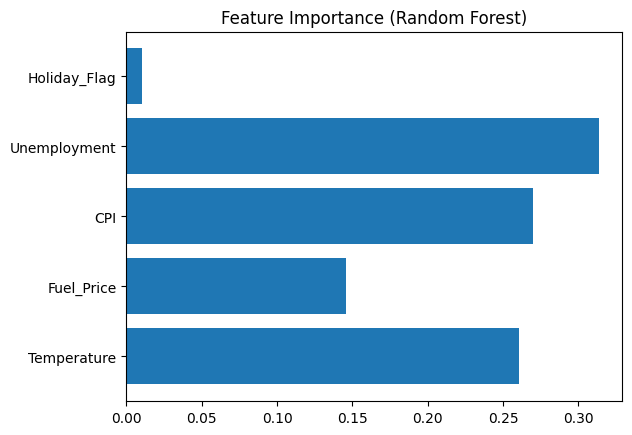

In [16]:
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()